In [31]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [33]:
df = pd.read_csv('Iris (1).csv')

In [34]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [36]:
df = df.iloc[:,1:]


In [37]:
df.head()

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,Iris-setosa
1,3.0,1.4,0.2,Iris-setosa
2,3.2,1.3,0.2,Iris-setosa
3,3.1,1.5,0.2,Iris-setosa
4,3.6,1.4,0.2,Iris-setosa


In [38]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])

In [39]:
df.head()

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [40]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [41]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


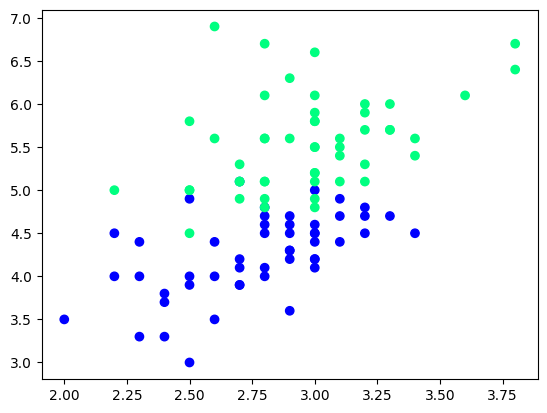

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [43]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
54,2.8,4.6,1
104,3.0,5.8,2
58,2.9,4.6,1
75,3.0,4.4,1
99,2.8,4.1,1
98,2.5,3.0,1
82,2.7,3.9,1
86,3.1,4.7,1
107,2.9,6.3,2
68,2.2,4.5,1


In [44]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [45]:
df_train

,SepalWidthCm,PetalLengthCm,Species
143,3.2,5.9,2
54,2.8,4.6,1
111,2.7,5.3,2
64,2.9,3.6,1
61,3.0,4.2,1
142,2.7,5.1,2
112,3.0,5.5,2
79,2.6,3.5,1
60,2.0,3.5,1
71,2.8,4.0,1


In [46]:
df_val

,SepalWidthCm,PetalLengthCm,Species
113,2.5,5.0,2
81,2.4,3.7,1
106,2.5,4.5,2
80,2.4,3.8,1
146,2.5,5.0,2


In [47]:
df_test

,SepalWidthCm,PetalLengthCm,Species
72,2.5,4.9,1
122,2.8,6.7,2
66,3.0,4.5,1
127,3.0,4.9,2
97,2.9,4.3,1


In [48]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [49]:
y_test

array([2, 1, 2, 1, 2])

In [50]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
79,2.6,3.5,1
60,2.0,3.5,1
61,3.0,4.2,1
71,2.8,4.0,1
112,3.0,5.5,2
54,2.8,4.6,1
112,3.0,5.5,2
60,2.0,3.5,1


In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score



In [52]:
dt_bag1 = DecisionTreeClassifier()

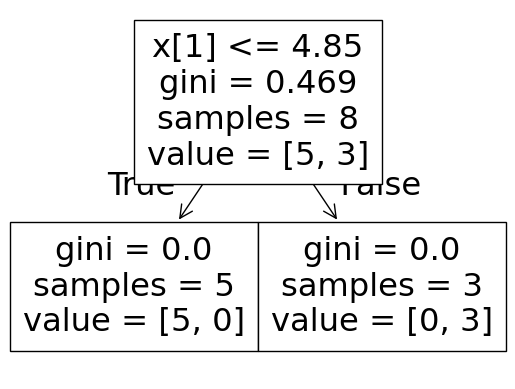

c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


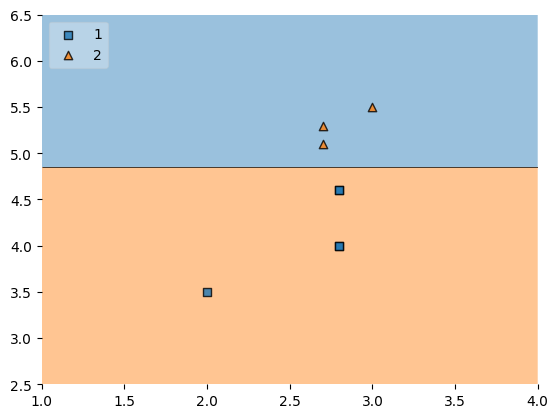

In [59]:
evaluate(dt_bag1,X,y)

In [54]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
61,3.0,4.2,1
60,2.0,3.5,1
64,2.9,3.6,1
60,2.0,3.5,1
60,2.0,3.5,1
143,3.2,5.9,2
112,3.0,5.5,2
54,2.8,4.6,1


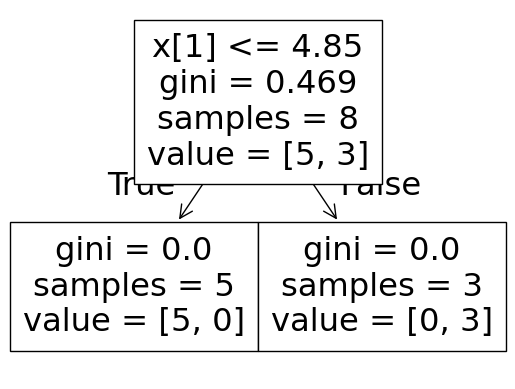

c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


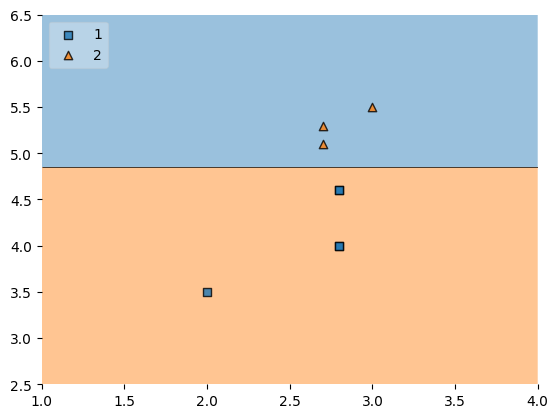

In [60]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [61]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
60,2.0,3.5,1
60,2.0,3.5,1
111,2.7,5.3,2
71,2.8,4.0,1
112,3.0,5.5,2
112,3.0,5.5,2
60,2.0,3.5,1
143,3.2,5.9,2


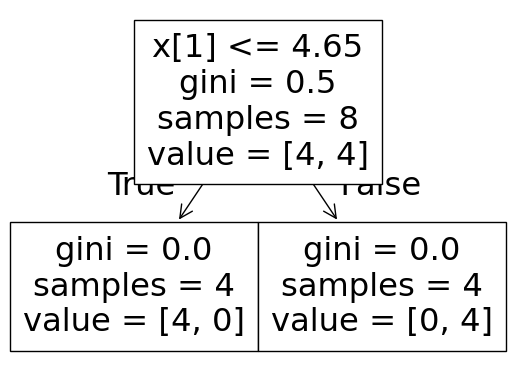

c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


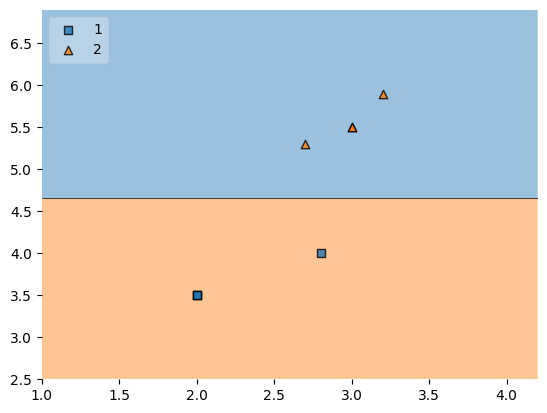

In [62]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [57]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [63]:
df_test

,SepalWidthCm,PetalLengthCm,Species
72,2.5,4.9,1
122,2.8,6.7,2
66,3.0,4.5,1
127,3.0,4.9,2
97,2.9,4.3,1


In [64]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [65]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
143,3.2,5.9,2
54,2.8,4.6,1
111,2.7,5.3,2
64,2.9,3.6,1
61,3.0,4.2,1
142,2.7,5.1,2
112,3.0,5.5,2
79,2.6,3.5,1
60,2.0,3.5,1
71,2.8,4.0,1


In [66]:

df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
71,2.8,4.0,1
79,2.6,3.5,1
142,2.7,5.1,2
60,2.0,3.5,1
143,3.2,5.9,2
64,2.9,3.6,1
61,3.0,4.2,1
112,3.0,5.5,2


In [68]:
df1 = pd.read_csv('Iris (1).csv')
df1 = df1.sample(10)

In [69]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
39,40,5.1,3.4,1.5,0.2,Iris-setosa
60,61,5.0,2.0,3.5,1.0,Iris-versicolor
4,5,5.0,3.6,1.4,0.2,Iris-setosa
113,114,5.7,2.5,5.0,2.0,Iris-virginica
49,50,5.0,3.3,1.4,0.2,Iris-setosa
47,48,4.6,3.2,1.4,0.2,Iris-setosa
79,80,5.7,2.6,3.5,1.0,Iris-versicolor
48,49,5.3,3.7,1.5,0.2,Iris-setosa
72,73,6.3,2.5,4.9,1.5,Iris-versicolor
100,101,6.3,3.3,6.0,2.5,Iris-virginica


In [70]:
df1.sample(2,replace=True,axis=1)

,Species,PetalWidthCm
39,Iris-setosa,0.2
60,Iris-versicolor,1.0
4,Iris-setosa,0.2
113,Iris-virginica,2.0
49,Iris-setosa,0.2
47,Iris-setosa,0.2
79,Iris-versicolor,1.0
48,Iris-setosa,0.2
72,Iris-versicolor,1.5
100,Iris-virginica,2.5


In [71]:

df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
39,40,5.1,3.4,1.5,0.2,Iris-setosa
60,61,5.0,2.0,3.5,1.0,Iris-versicolor
4,5,5.0,3.6,1.4,0.2,Iris-setosa
113,114,5.7,2.5,5.0,2.0,Iris-virginica
49,50,5.0,3.3,1.4,0.2,Iris-setosa
47,48,4.6,3.2,1.4,0.2,Iris-setosa
79,80,5.7,2.6,3.5,1.0,Iris-versicolor
48,49,5.3,3.7,1.5,0.2,Iris-setosa
72,73,6.3,2.5,4.9,1.5,Iris-versicolor
100,101,6.3,3.3,6.0,2.5,Iris-virginica


In [72]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalWidthCm,Id
79,1.0,80
39,0.2,40
60,1.0,61
100,2.5,101
79,1.0,80
100,2.5,101
113,2.0,114
49,0.2,50
